In [1]:
from google.colab import files
uploaded = files.upload()

Saving JME_Country_Estimates_April_2021.xlsx to JME_Country_Estimates_April_2021.xlsx


Dataset Loaded Successfully

Initial Shape: (611, 25)

Detected Year Columns:
['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019']

Shape After Cleaning: (465, 25)


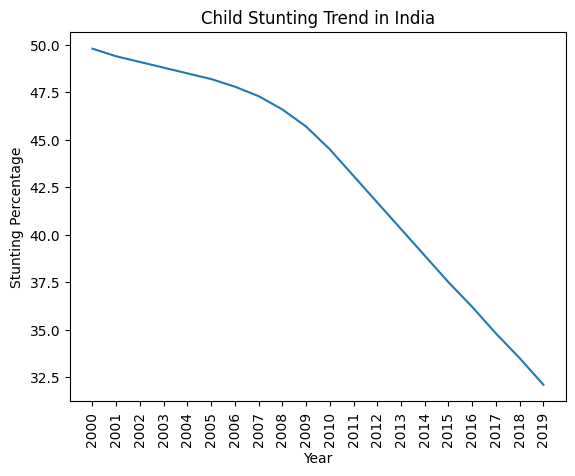

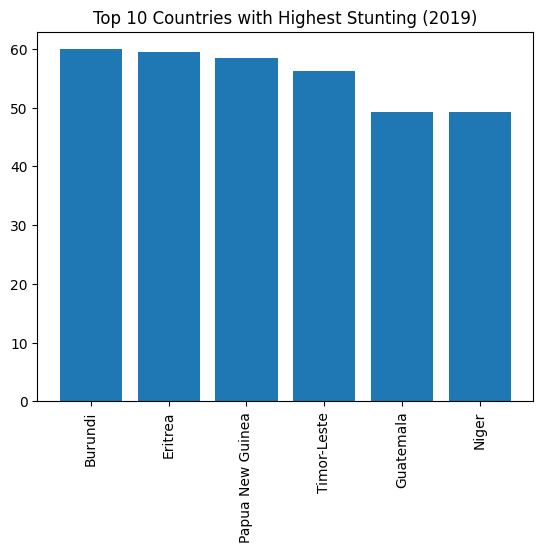


Model Training Completed

Model Performance:
Mean Squared Error: 0.01897642900063629
R2 Score: 0.9998983615264875


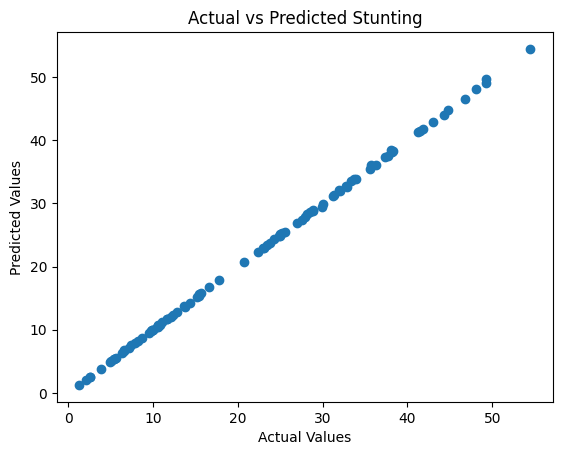


Sample Prediction: [15.60419095]


In [5]:
# ============================================
# CHILD GROWTH MONITOR USING UNICEF SDG DATA
# FINAL CLEAN CODE (ERROR-FREE)
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ============================================
# Step 1: Load Dataset
# ============================================

file_name = "JME_Country_Estimates_April_2021.xlsx"

data = pd.read_excel(
    file_name,
    sheet_name="Stunting Proportion (Model)"
)

print("Dataset Loaded Successfully\n")


# ============================================
# Step 2: Basic Cleaning
# ============================================

# Drop unnecessary columns
data = data.drop(columns=["ISO code", "Note"], errors='ignore')

print("Initial Shape:", data.shape)


# ============================================
# Step 3: Identify Year Columns (AUTO DETECT)
# ============================================

# Detect numeric year columns like 2000, 2001...
year_columns = [col for col in data.columns if str(col).strip().isdigit()]

# Backup if above fails
if len(year_columns) == 0:
    year_columns = data.columns[4:]   # skip first columns

print("\nDetected Year Columns:")
print(year_columns)


# ============================================
# Step 4: Convert Data to Numeric (IMPORTANT FIX)
# ============================================

# Replace '-' with NaN
data.replace("-", np.nan, inplace=True)

# Convert year columns to numeric
for col in year_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop missing values
data = data.dropna()

print("\nShape After Cleaning:", data.shape)


# ============================================
# Step 5: Visualization - India Trend
# ============================================

country_data = data[data["Country and areas"] == "India"]

if not country_data.empty:
    values = country_data.iloc[0][year_columns]

    plt.figure()
    plt.plot(year_columns, values)
    plt.title("Child Stunting Trend in India")
    plt.xlabel("Year")
    plt.ylabel("Stunting Percentage")
    plt.xticks(rotation=90)
    plt.show()
else:
    print("India data not found")


# ============================================
# Step 6: Visualization - Top 10 Countries
# ============================================

last_year = year_columns[-1]

top_countries = data.sort_values(
    by=last_year,
    ascending=False
).head(10)

plt.figure()
plt.bar(top_countries["Country and areas"], top_countries[last_year])
plt.title(f"Top 10 Countries with Highest Stunting ({last_year})")
plt.xticks(rotation=90)
plt.show()


# ============================================
# Step 7: Prepare Machine Learning Data
# ============================================

# Input = all years except last
X = data[year_columns[:-1]]

# Output = last year
y = data[last_year]


# ============================================
# Step 8: Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ============================================
# Step 9: Train Model
# ============================================

model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Training Completed")


# ============================================
# Step 10: Predictions
# ============================================

y_pred = model.predict(X_test)


# ============================================
# Step 11: Model Evaluation
# ============================================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


# ============================================
# Step 12: Actual vs Predicted Graph
# ============================================

plt.figure()
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted Stunting")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()


# ============================================
# Step 13: Sample Prediction
# ============================================

sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("\nSample Prediction:", prediction)